In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_train = pd.read_csv('training_dataset.csv')
df_train

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,...,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22911,680377,32,teknisi,menikah,Diploma,no,yes,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.967,5228.1,Kalimantan,0
22912,505429,30,mahasiswa,lajang,Diploma,no,no,no,telephone,sep,...,999,0,nonexistent,-1.1,94.199,-37.5,0.880,4963.6,Bali,0
22913,308952,29,manajer,lajang,SMA,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,NTT,0
22914,865813,52,entrepreneur,menikah,Tidak Tamat SD,unknown,yes,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.960,5228.1,NTB,0


In [ ]:
df_val = pd.read_csv('validation_set.csv')
df_val

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,445420,35,penyedia jasa,menikah,SMA,no,yes,yes,cellular,jul,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,Jawa
1,585604,52,teknisi,lajang,Diploma,unknown,no,no,telephone,may,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,Papua
2,888824,37,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,Bali
3,816820,51,pengangguran,menikah,Diploma,no,no,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Sumatera
4,542716,45,teknisi,cerai,SMA,no,yes,no,cellular,may,...,1,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1,Sumatera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,782072,51,pekerja kasar,menikah,Tidak Tamat SD,no,yes,no,telephone,jun,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,Kalimantan
5725,116371,30,pekerja kasar,menikah,SMP,no,yes,yes,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,Sulawesi
5726,773759,45,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,NTB
5727,612330,60,teknisi,menikah,Diploma,unknown,no,no,telephone,jul,...,15,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,Papua


In [ ]:
print("Shape train:", df_train.shape)
print("Shape val:", df_val.shape)


Shape train: (22916, 22)
Shape val: (5729, 21)


In [ ]:
print("\nTrain info:")
print(df_train.info())

print("\nValidation info:")
print(df_val.info())


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  i

In [ ]:
print("\nMissing values train:\n", df_train.isnull().sum())
print("\nMissing values val:\n", df_val.isnull().sum())


Missing values train:
 customer_number                 0
usia                            0
pekerjaan                       0
status_perkawinan               0
pendidikan                      0
gagal_bayar_sebelumnya          0
pinjaman_rumah                  0
pinjaman_pribadi                0
jenis_kontak                    0
bulan_kontak_terakhir           0
hari_kontak_terakhir            0
jumlah_kontak_kampanye_ini      0
hari_sejak_kontak_sebelumnya    0
jumlah_kontak_sebelumnya        0
hasil_kampanye_sebelumnya       0
tingkat_variasi_pekerjaan       0
indeks_harga_konsumen           0
indeks_kepercayaan_konsumen     0
suku_bunga_euribor_3bln         0
jumlah_pekerja                  0
pulau                           0
berlangganan_deposito           0
dtype: int64

Missing values val:
 customer_number                 0
usia                            0
pekerjaan                       0
status_perkawinan               0
pendidikan                      0
gagal_bayar_sebelumnya 

In [ ]:
print("\nDescriptive stats train:")
print(df_train.describe())
print("\nDescriptive stats val:")
print(df_val.describe())


Descriptive stats train:
       customer_number          usia  jumlah_kontak_kampanye_ini  \
count     22916.000000  22916.000000                22916.000000   
mean     550930.993193     40.016233                    2.561878   
std      259909.889175     10.438059                    2.794178   
min      100108.000000     17.000000                    1.000000   
25%      325755.000000     32.000000                    1.000000   
50%      553139.000000     38.000000                    2.000000   
75%      777157.500000     47.000000                    3.000000   
max      999997.000000     98.000000                   42.000000   

       hari_sejak_kontak_sebelumnya  jumlah_kontak_sebelumnya  \
count                  22916.000000              22916.000000   
mean                     962.210377                  0.170143   
std                      187.566774                  0.490611   
min                        0.000000                  0.000000   
25%                      999.000000 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

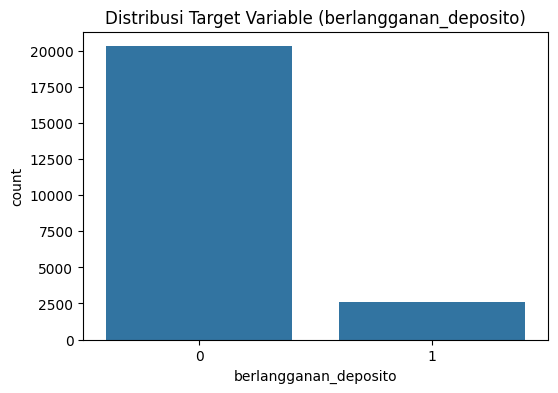

berlangganan_deposito
0    0.885931
1    0.114069
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='berlangganan_deposito', data=df_train)
plt.title('Distribusi Target Variable (berlangganan_deposito)')
plt.show()

print(df_train['berlangganan_deposito'].value_counts(normalize=True))

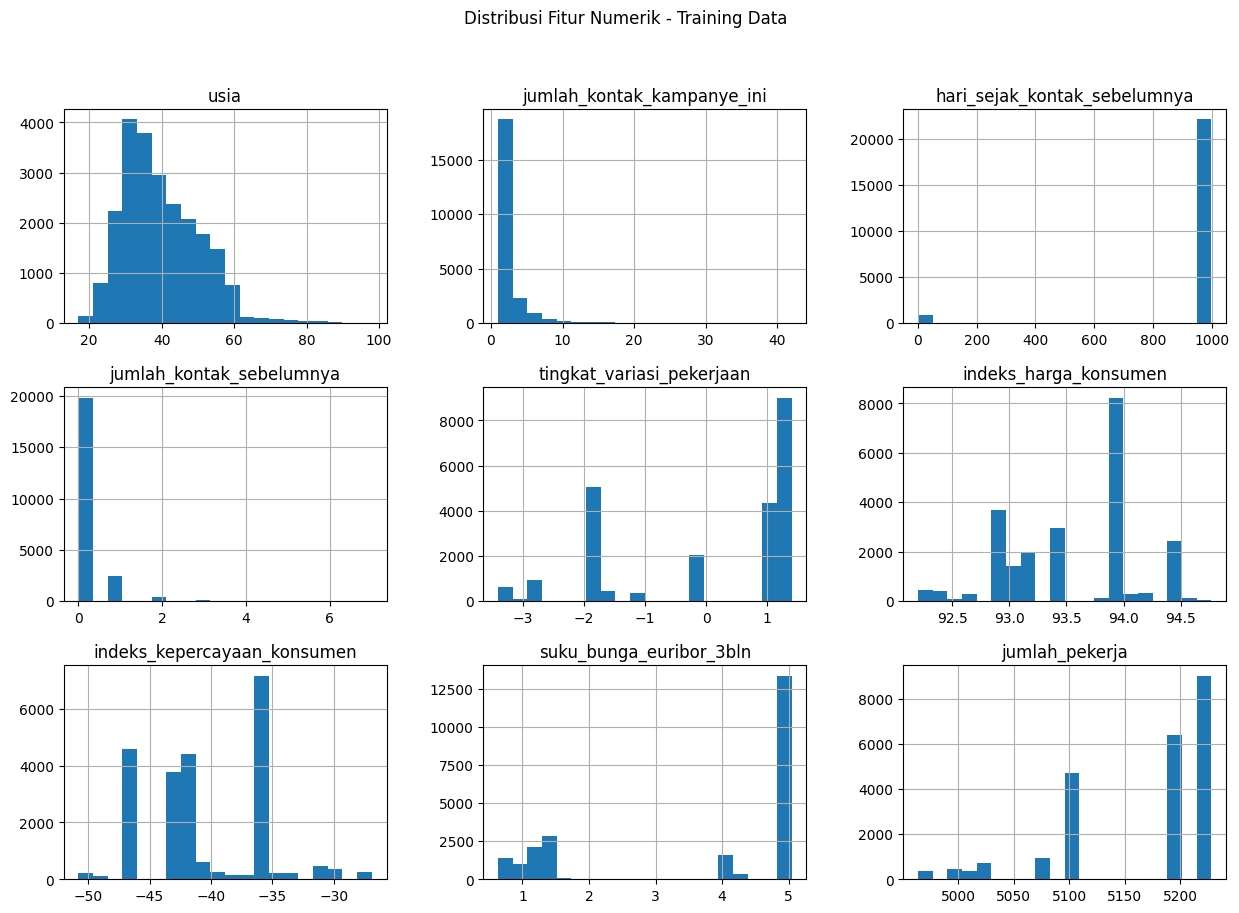

In [ ]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# hapus kolom id jika ada (customer_number)
if 'customer_number' in num_cols:
    num_cols.remove('customer_number')
if 'berlangganan_deposito' in num_cols:
    num_cols.remove('berlangganan_deposito')

df_train[num_cols].hist(bins=20, figsize=(15,10))
plt.suptitle('Distribusi Fitur Numerik - Training Data')
plt.show()

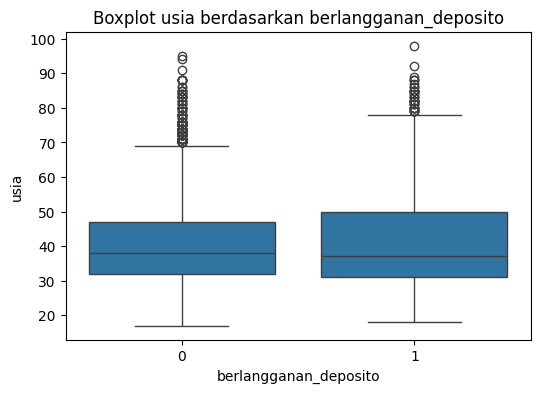

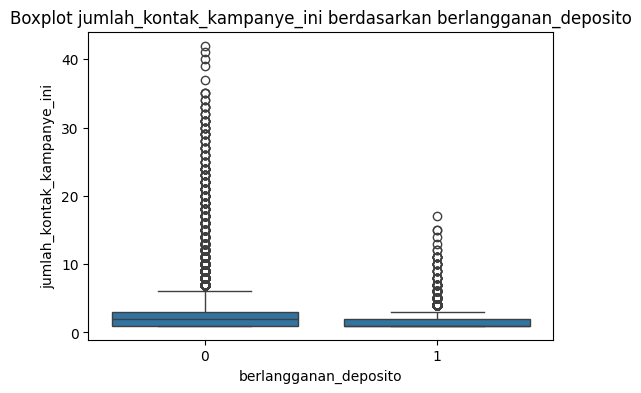

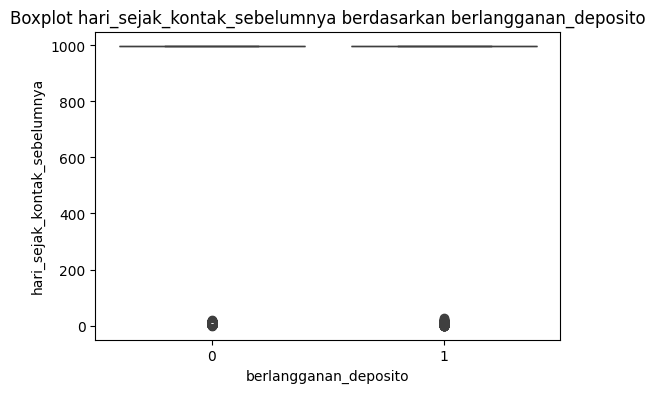

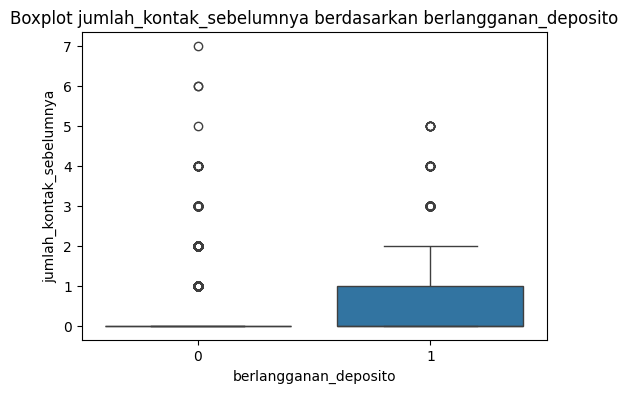

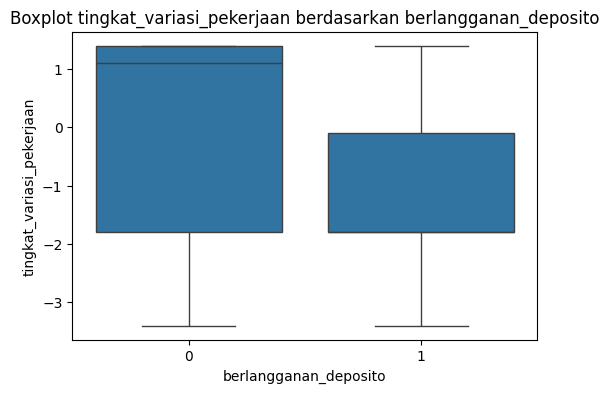

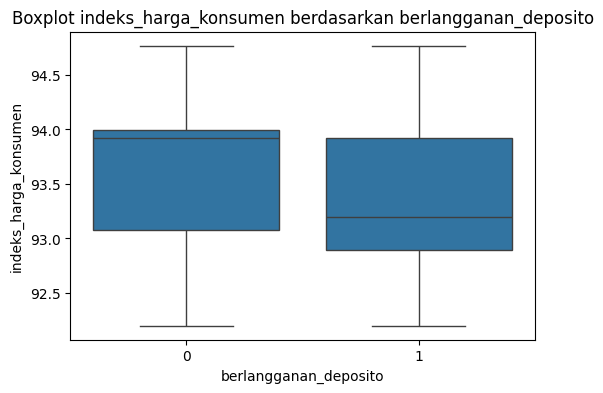

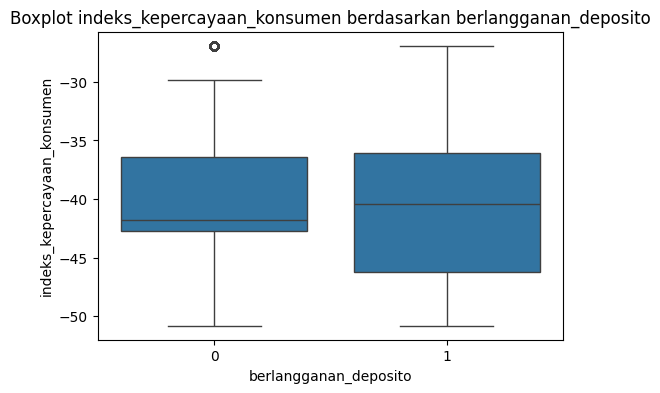

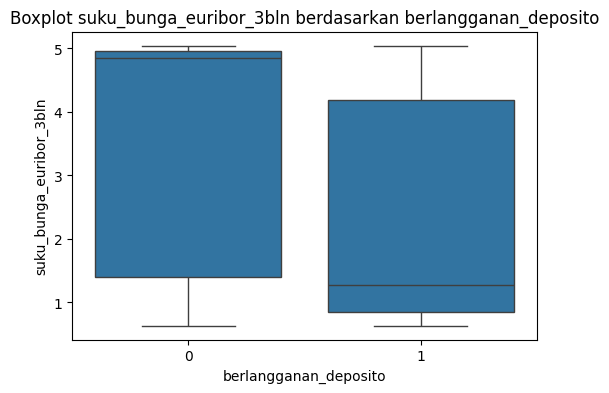

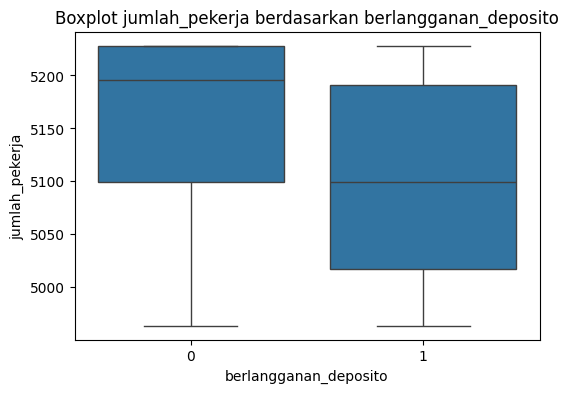

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='berlangganan_deposito', y=col, data=df_train)
    plt.title(f'Boxplot {col} berdasarkan berlangganan_deposito')
    plt.show()


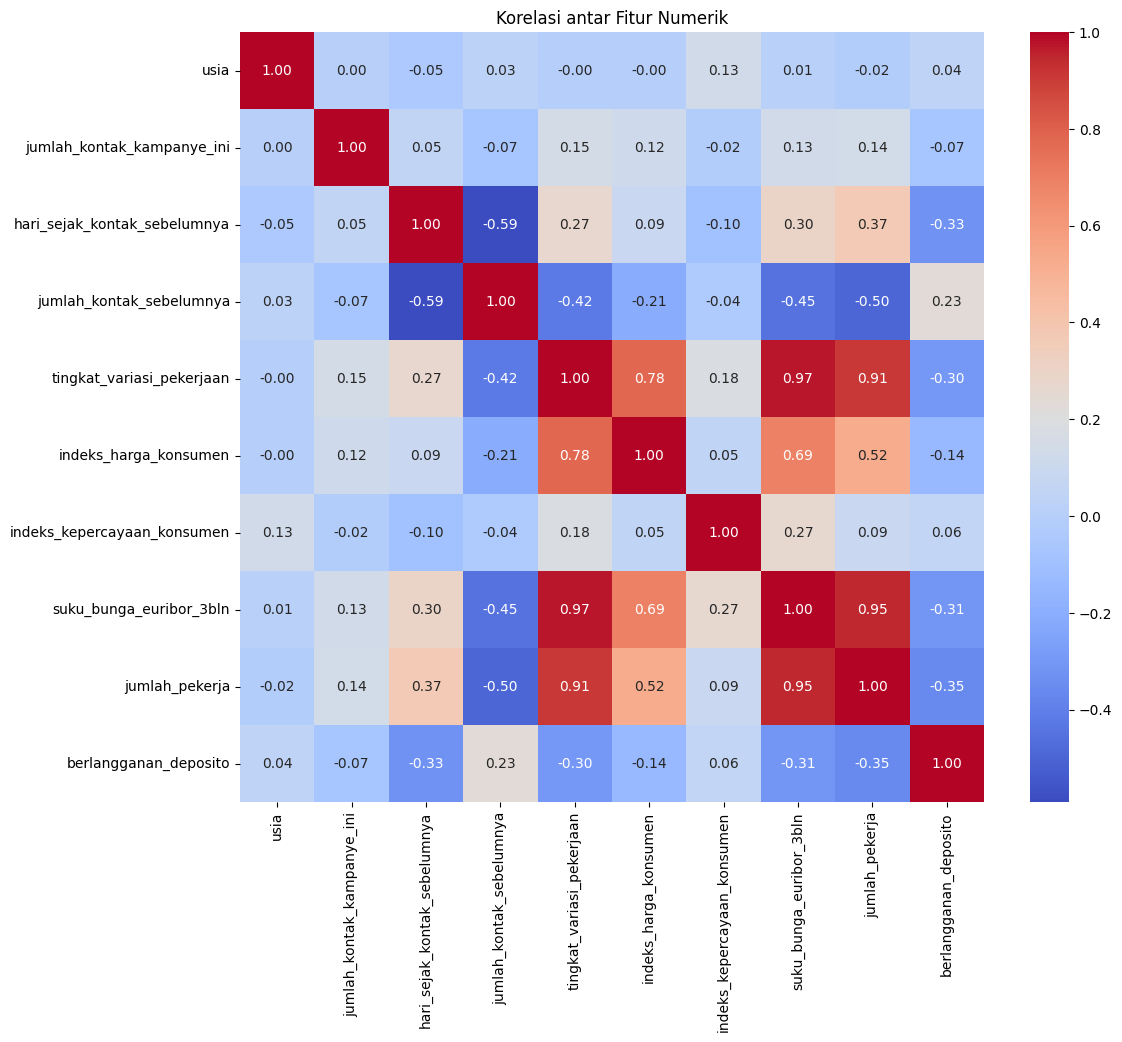

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df_train[num_cols + ['berlangganan_deposito']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()

Fitur kategorikal: ['pekerjaan', 'status_perkawinan', 'pendidikan', 'gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi', 'jenis_kontak', 'bulan_kontak_terakhir', 'hari_kontak_terakhir', 'hasil_kampanye_sebelumnya', 'pulau']


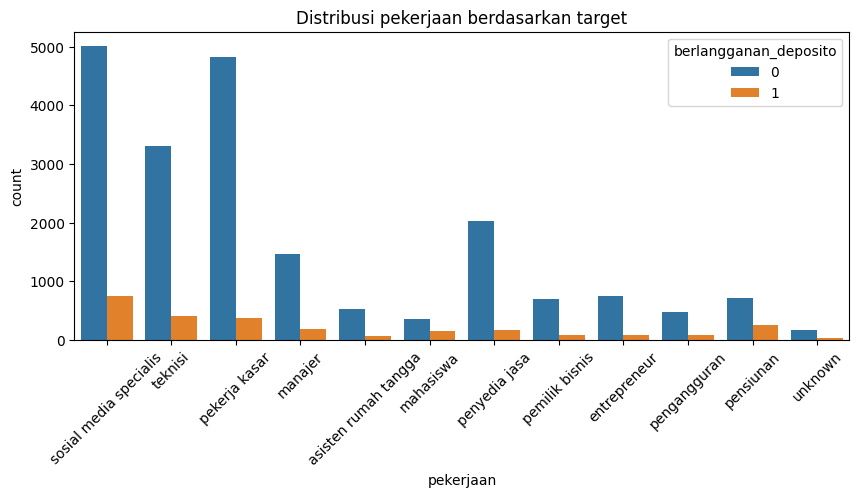

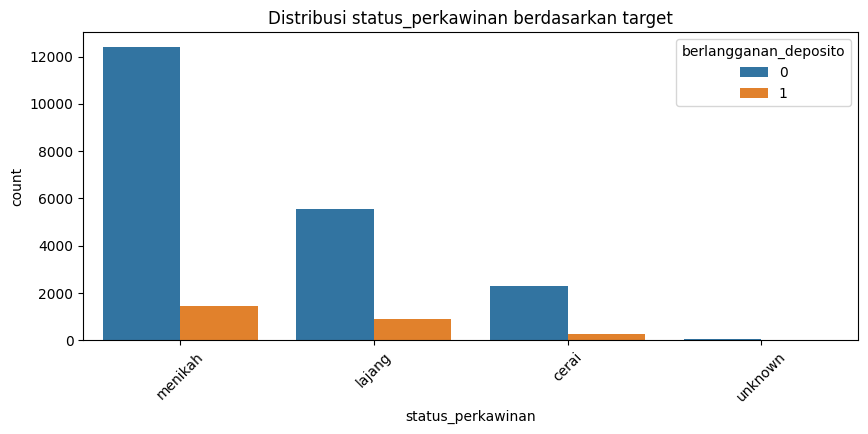

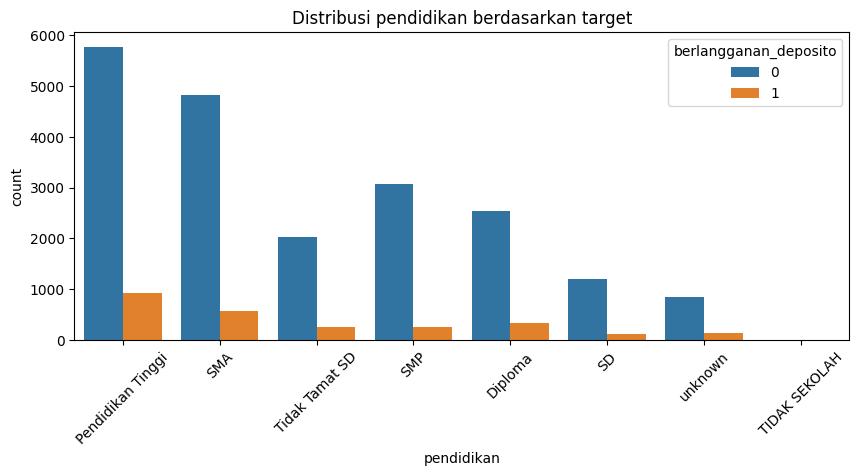

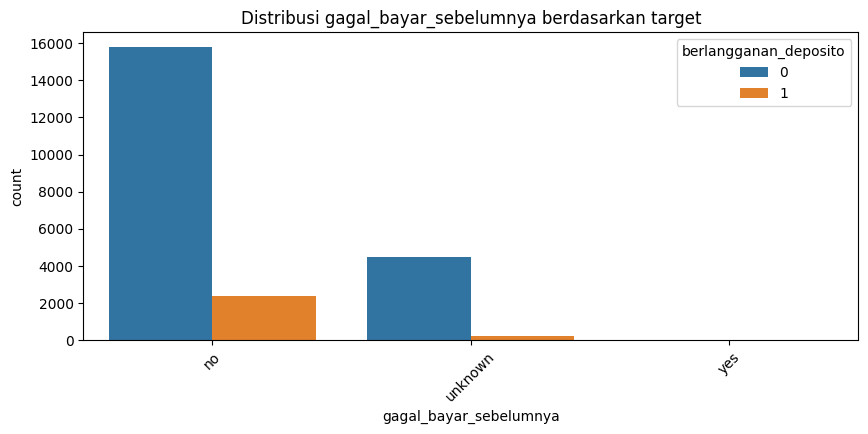

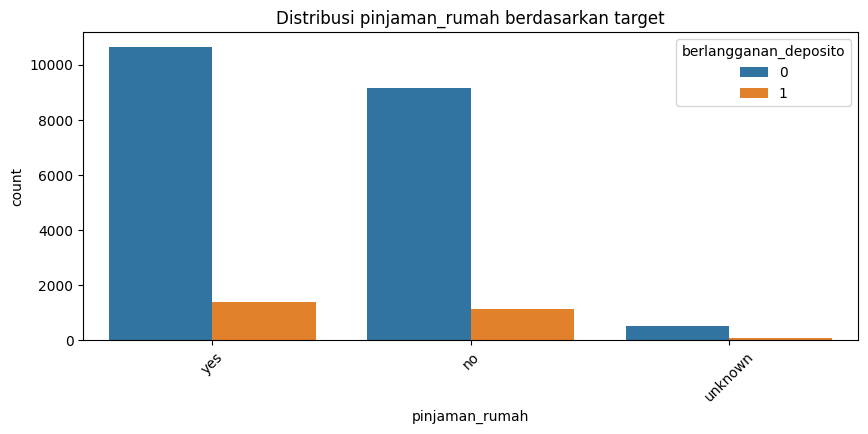

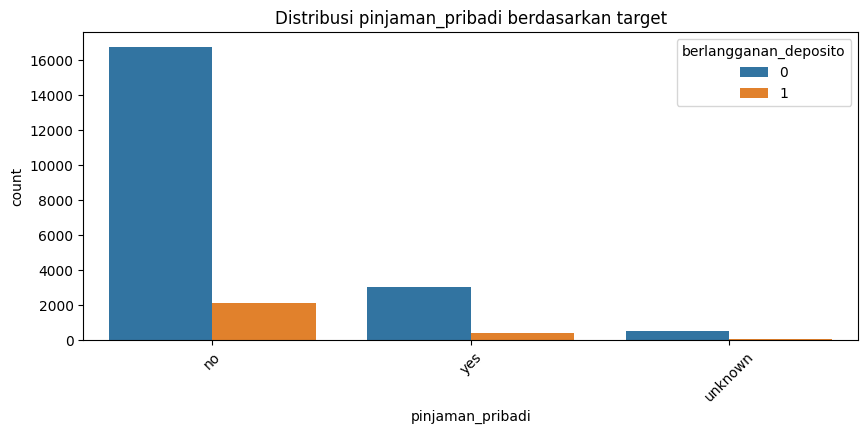

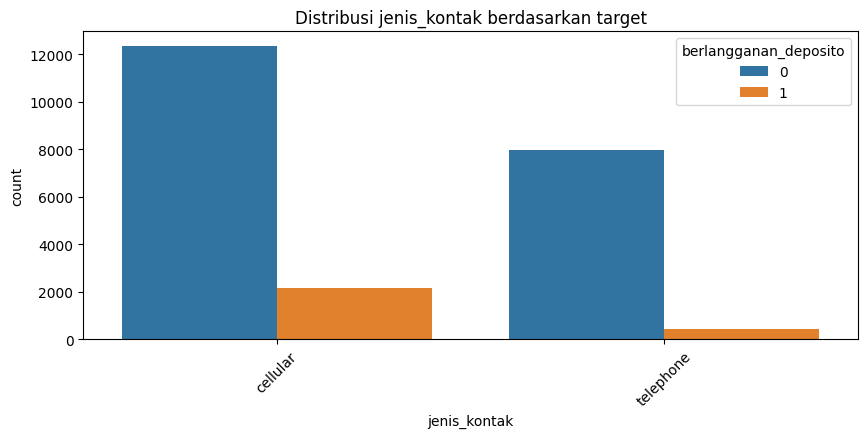

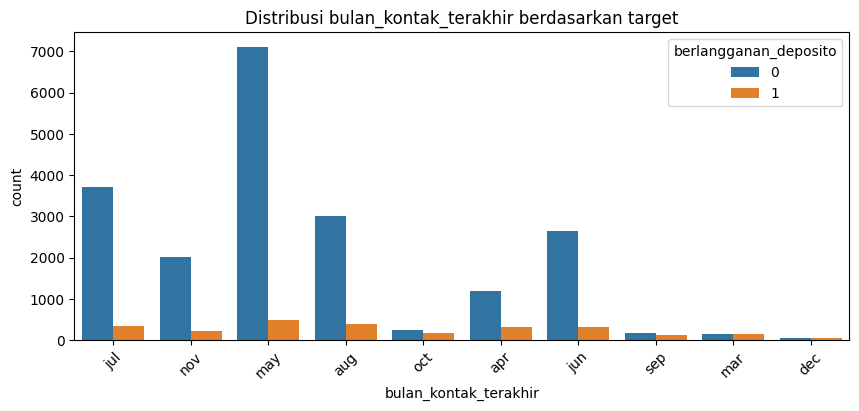

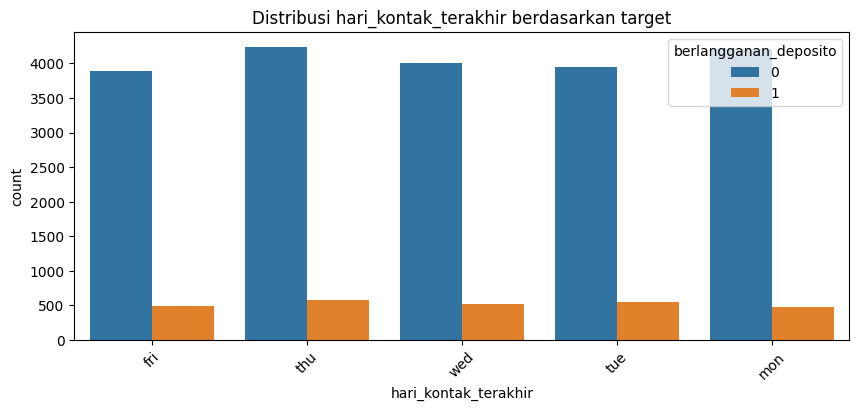

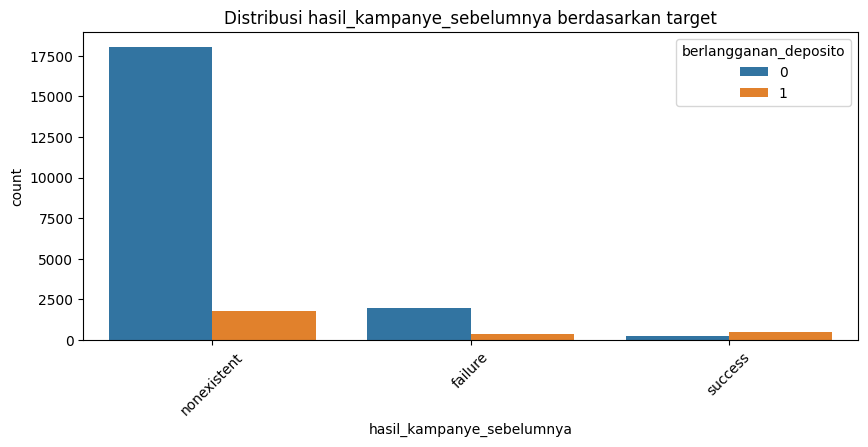

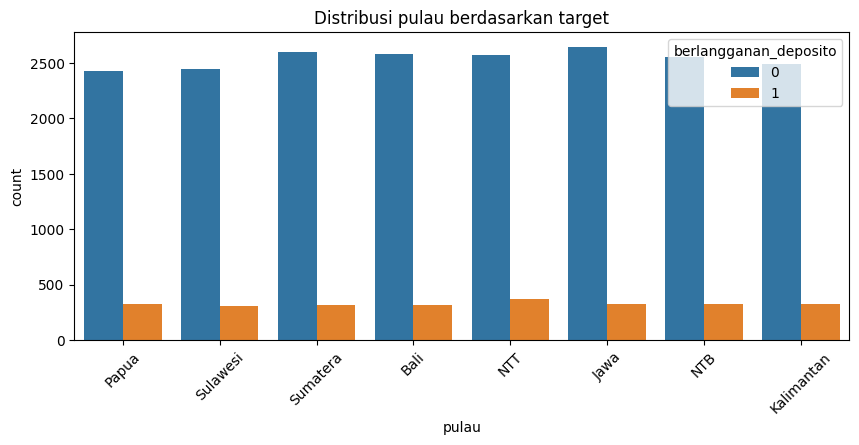

In [ ]:
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()
print("Fitur kategorikal:", cat_cols)

for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df_train, x=col, hue='berlangganan_deposito')
    plt.title(f'Distribusi {col} berdasarkan target')
    plt.xticks(rotation=45)
    plt.show()

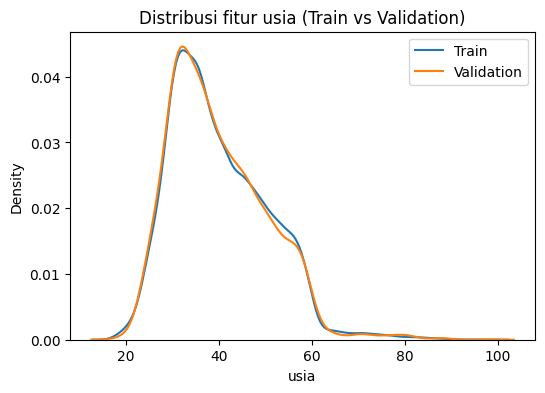

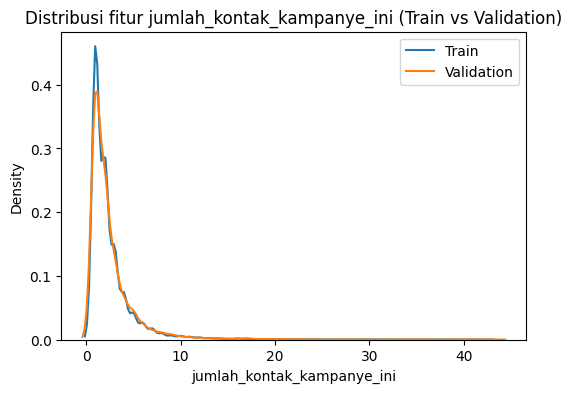

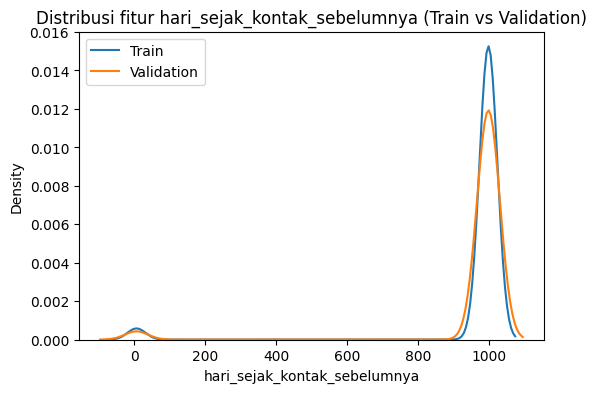

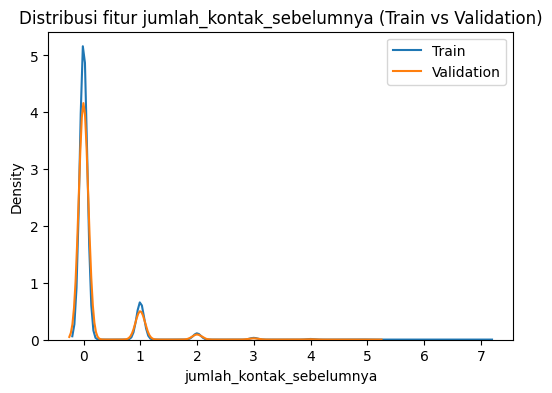

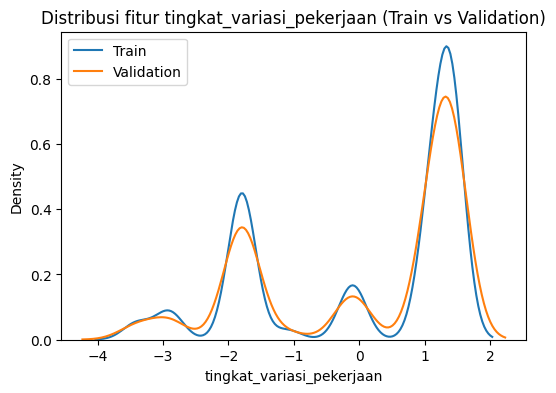

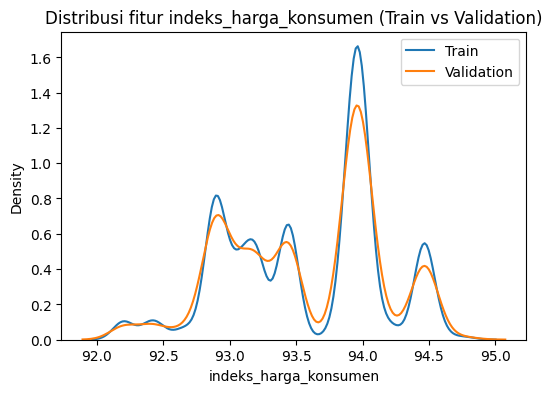

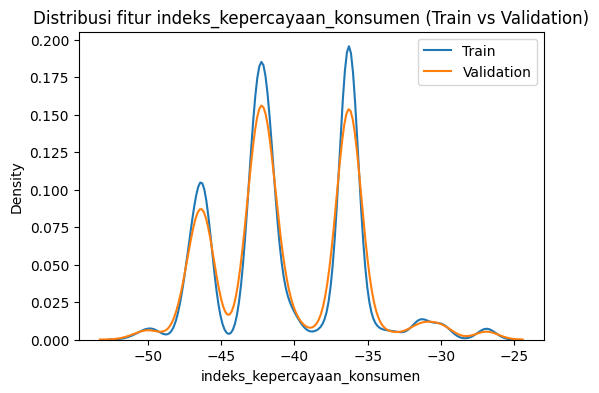

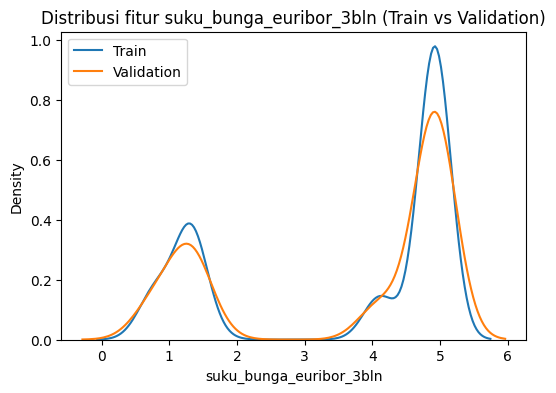

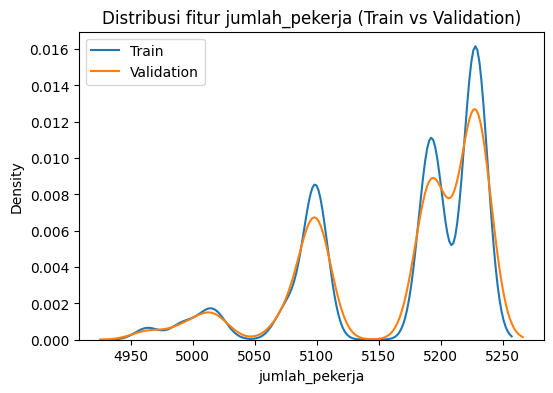

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df_train[col], label='Train')
    sns.kdeplot(df_val[col], label='Validation')
    plt.title(f'Distribusi fitur {col} (Train vs Validation)')
    plt.legend()
    plt.show()

<Figure size 1000x400 with 0 Axes>

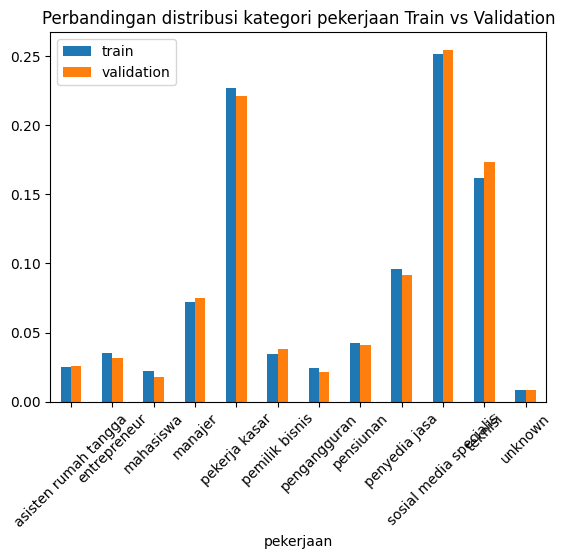

<Figure size 1000x400 with 0 Axes>

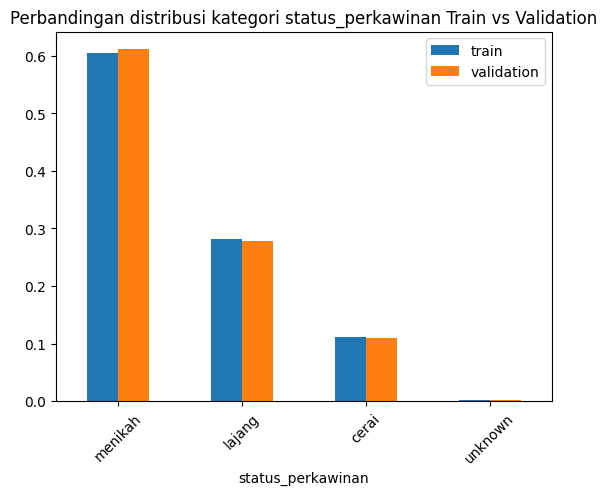

<Figure size 1000x400 with 0 Axes>

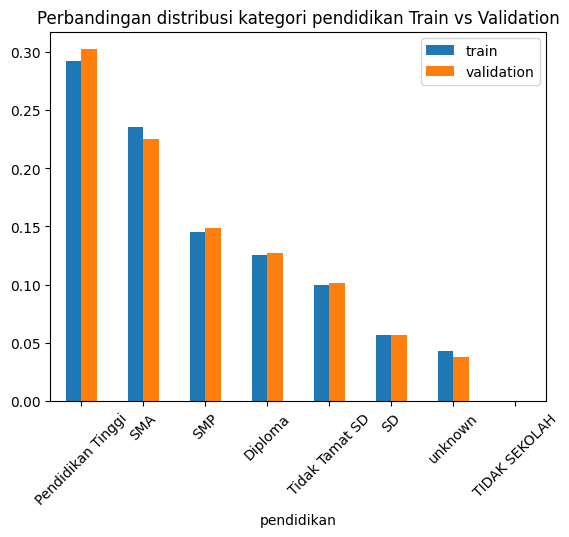

<Figure size 1000x400 with 0 Axes>

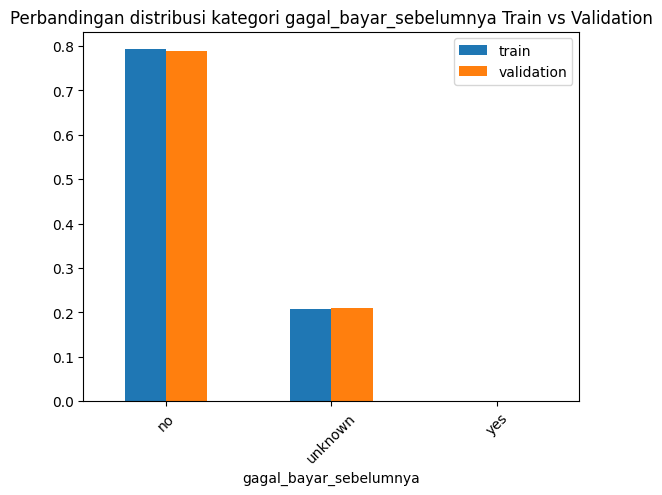

<Figure size 1000x400 with 0 Axes>

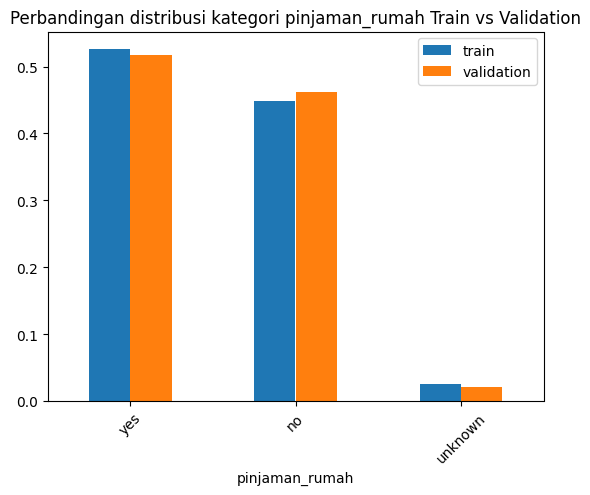

<Figure size 1000x400 with 0 Axes>

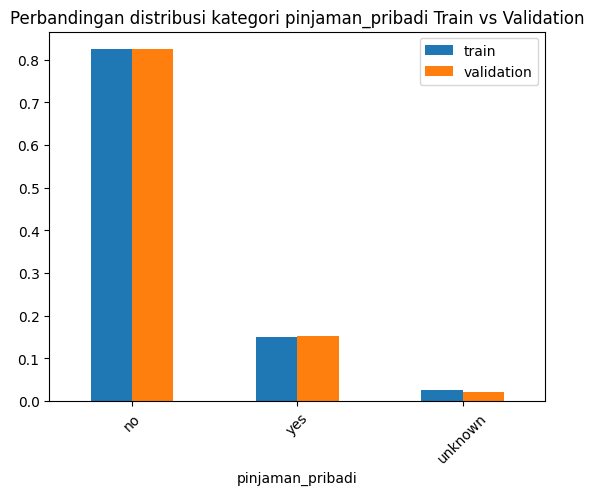

<Figure size 1000x400 with 0 Axes>

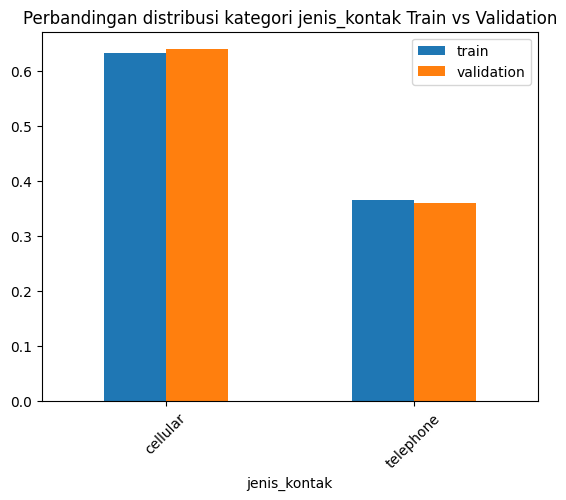

<Figure size 1000x400 with 0 Axes>

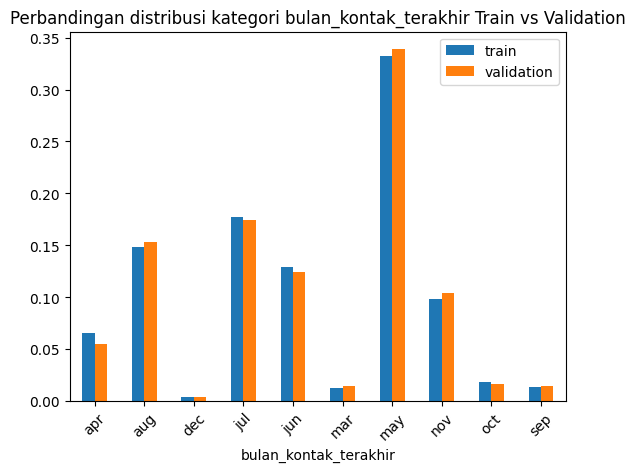

<Figure size 1000x400 with 0 Axes>

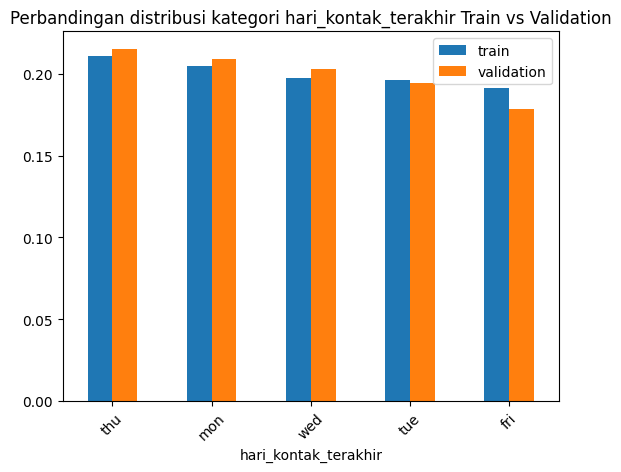

<Figure size 1000x400 with 0 Axes>

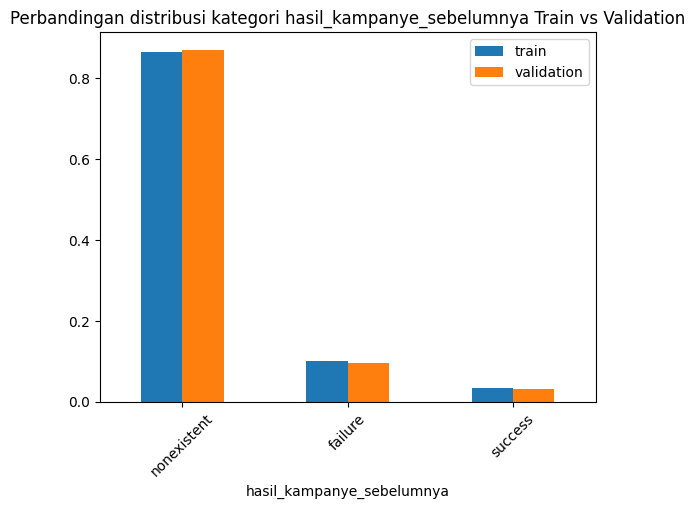

<Figure size 1000x400 with 0 Axes>

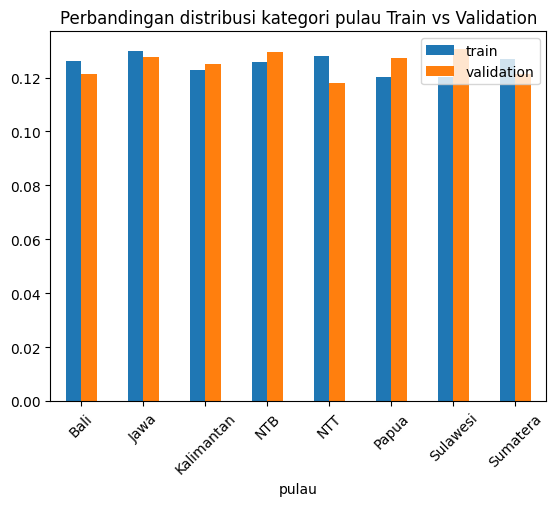

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    train_counts = df_train[col].value_counts(normalize=True)
    val_counts = df_val[col].value_counts(normalize=True)
    df_compare = pd.DataFrame({'train': train_counts, 'validation': val_counts}).fillna(0)
    df_compare.plot(kind='bar')
    plt.title(f'Perbandingan distribusi kategori {col} Train vs Validation')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
cols_to_drop = ['customer_number']


In [ ]:
df_train_model = df_train.drop(columns=cols_to_drop)
df_val_model = df_val.drop(columns=cols_to_drop)

In [ ]:
X_train = df_train_model.drop(columns=['berlangganan_deposito'])
y_train = df_train_model['berlangganan_deposito']

In [ ]:
X_val = df_val_model.copy()

print("Fitur train shape:", X_train.shape)
print("Target train shape:", y_train.shape)
print("Fitur val shape:", X_val.shape)

Fitur train shape: (22916, 20)
Target train shape: (22916,)
Fitur val shape: (5729, 20)


In [ ]:
print(y_train.value_counts(normalize=True))


berlangganan_deposito
0    0.885931
1    0.114069
Name: proportion, dtype: float64


In [ ]:
from imblearn.over_sampling import RandomOverSampler


In [ ]:
ros = RandomOverSampler(random_state=42)


In [ ]:
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)


In [ ]:
print("Distribusi kelas setelah oversampling:")
print(y_train_res.value_counts())

Distribusi kelas setelah oversampling:
berlangganan_deposito
1    20302
0    20302
Name: count, dtype: int64


In [ ]:
print("Shape X_train_res:", X_train_res.shape)
print("Shape y_train_res:", y_train_res.shape)

Shape X_train_res: (40604, 20)
Shape y_train_res: (40604,)


In [ ]:
categorical_cols = [
    'pekerjaan',
    'status_perkawinan',
    'pendidikan',
    'jenis_kontak',
    'bulan_kontak_terakhir',
    'hasil_kampanye_sebelumnya',
    'pulau'
]


In [ ]:
X_all = pd.concat([X_train, X_val], keys=['train', 'val'])


In [ ]:
X_all_encoded = pd.get_dummies(X_all, columns=categorical_cols, drop_first=True)


In [ ]:
X_train_encoded = X_all_encoded.loc['train']
X_val_encoded = X_all_encoded.loc['val']

In [ ]:
print("Shape X_train_encoded:", X_train_encoded.shape)
print("Shape X_val_encoded:", X_val_encoded.shape)

Shape X_train_encoded: (22916, 53)
Shape X_val_encoded: (5729, 53)


In [ ]:
categorical_cols += ['hari_kontak_terakhir']

X_all = pd.concat([X_train, X_val], keys=['train', 'val'])
X_all_encoded = pd.get_dummies(X_all, columns=categorical_cols, drop_first=True)

X_train_encoded = X_all_encoded.loc['train']
X_val_encoded = X_all_encoded.loc['val']

In [ ]:
X_train_encoded_clean = X_train_encoded.copy()

binary_cols = ['gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi']
binary_map = {'yes': 1, 'no': 0, 'unknown': -1}

for col in binary_cols:
    X_train_encoded_clean[col] = X_train_encoded_clean[col].map(binary_map)


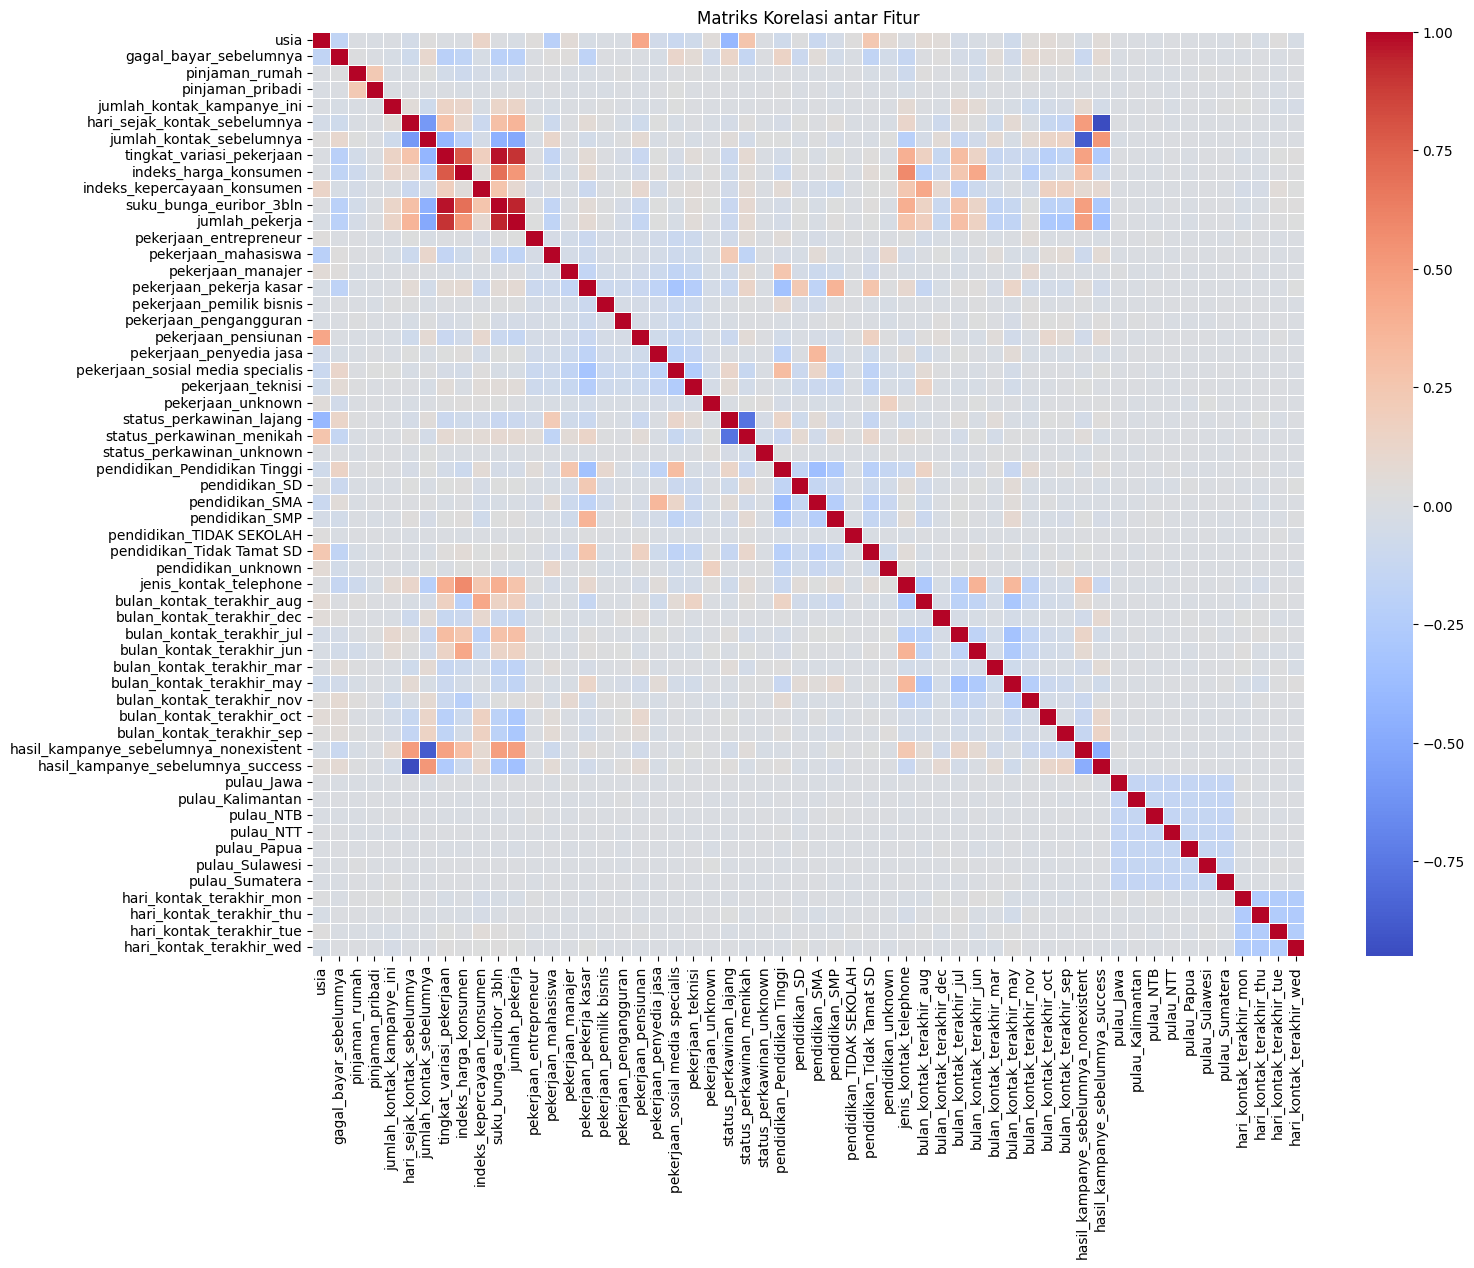

In [ ]:
corr_matrix = X_train_encoded_clean.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi antar Fitur')
plt.show()


In [ ]:
X_corr = X_train_encoded.copy()

binary_cols = ['gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi']
binary_map = {'yes': 1, 'no': 0, 'unknown': -1}

for col in binary_cols:
    X_corr[col] = X_corr[col].map(binary_map)

X_corr['berlangganan_deposito'] = y_train

correlation_with_target = X_corr.corr()['berlangganan_deposito'].sort_values(ascending=False)

print("Korelasi fitur terhadap target 'berlangganan_deposito':\n")
print(correlation_with_target)


Korelasi fitur terhadap target 'berlangganan_deposito':

berlangganan_deposito                    1.000000
hasil_kampanye_sebelumnya_success        0.315593
jumlah_kontak_sebelumnya                 0.231185
bulan_kontak_terakhir_oct                0.136950
bulan_kontak_terakhir_mar                0.132770
bulan_kontak_terakhir_sep                0.118516
gagal_bayar_sebelumnya                   0.099233
pekerjaan_pensiunan                      0.094577
pekerjaan_mahasiswa                      0.089336
bulan_kontak_terakhir_dec                0.074989
indeks_kepercayaan_konsumen              0.057904
status_perkawinan_lajang                 0.049102
pendidikan_Pendidikan Tinggi             0.048848
usia                                     0.038054
pekerjaan_sosial media specialis         0.029290
pendidikan_unknown                       0.020805
pekerjaan_pengangguran                   0.020437
pulau_NTT                                0.012917
hari_kontak_terakhir_thu                 0.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

In [ ]:
binary_map = {'yes': 1, 'no': 0, 'unknown': -1}
binary_cols = ['gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi']

for col in binary_cols:
    if col in X_train_encoded.columns:
        X_train_encoded[col] = X_train_encoded[col].map(binary_map)
        X_val_encoded[col] = X_val_encoded[col].map(binary_map)


<ipython-input-49-3237328065>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_encoded[col] = X_train_encoded[col].map(binary_map)
<ipython-input-49-3237328065>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val_encoded[col] = X_val_encoded[col].map(binary_map)
<ipython-input-49-3237328065>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

In [ ]:
non_numeric = X_train_encoded.select_dtypes(include=['object']).columns
print("Kolom non-numerik yang tersisa:", list(non_numeric))


Kolom non-numerik yang tersisa: []


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_encoded, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
selector = SelectFromModel(rf, prefit=True)

X_train_selected = selector.transform(X_train_encoded)
X_val_selected = selector.transform(X_val_encoded)

selected_features_mask = selector.get_support()
selected_feature_names = X_train_encoded.columns[selected_features_mask]

print(f"Jumlah fitur terpilih: {len(selected_feature_names)}")
print("Fitur penting:")
print(selected_feature_names.tolist())

Jumlah fitur terpilih: 13
Fitur penting:
['usia', 'pinjaman_rumah', 'pinjaman_pribadi', 'jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya', 'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen', 'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln', 'jumlah_pekerja', 'status_perkawinan_menikah', 'pendidikan_Pendidikan Tinggi', 'hasil_kampanye_sebelumnya_success']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.5 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
    "SVM": SVC(probability=True, random_state=42)
}

scoring = {
    'AUC': 'roc_auc',
    'F1': make_scorer(f1_score)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = X_train_encoded  # atau X_train_selected jika menggunakan fitur terpilih
y = y_train

results = pd.DataFrame(columns=['Model', 'AUC Mean', 'AUC Std', 'F1 Mean', 'F1 Std'])

for name, model in models.items():
    print(f"\nEvaluating {name}...")

    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

    results.loc[len(results)] = [
        name,
        auc_scores.mean(),
        auc_scores.std(),
        f1_scores.mean(),
        f1_scores.std()
    ]

    print(f"AUC: {auc_scores.mean():.4f} (±{auc_scores.std():.4f})")
    print(f"F1: {f1_scores.mean():.4f} (±{f1_scores.std():.4f})")

print("\n=== Hasil Perbandingan Model ===")
results = results.sort_values('AUC Mean', ascending=False)
display(results)



Evaluating Random Forest...
AUC: 0.7743 (±0.0086)
F1: 0.3641 (±0.0088)

Evaluating XGBoost...
AUC: 0.7712 (±0.0039)
F1: 0.3700 (±0.0175)

Evaluating LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2091, number of negative: 16241
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 508
[LightGBM] [Info] Number of data points in the train set: 18332, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.114063 -> initscore=-2.049896
[LightGBM] [Info] Start training from score -2.049896
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2091, number of negative: 16242
[LightGBM] [Info] Auto-choosing row-wise multi-threa

,Model,AUC Mean,AUC Std,F1 Mean,F1 Std
3,CatBoost,0.789244,0.007112,0.366605,0.011388
2,LightGBM,0.786689,0.005544,0.364131,0.014906
0,Random Forest,0.774306,0.008639,0.364140,0.008790
1,XGBoost,0.771166,0.003925,0.370018,0.017531
4,SVM,0.689260,0.040953,0.314754,0.016146


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64, 128]
}

cat_model = CatBoostClassifier(random_state=42, verbose=0)
search = RandomizedSearchCV(cat_model, param_dist, n_iter=20, cv=3, scoring='roc_auc')
search.fit(X_train_encoded, y_train)

print("Best parameters:", search.best_params_)
best_catboost = search.best_estimator_

Best parameters: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 4, 'border_count': 128}


In [ ]:
from sklearn.metrics import precision_recall_curve

y_probs = best_catboost.predict_proba(X_train_encoded)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_probs)

# Cari threshold yang memaksimalkan F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.2983981754120654


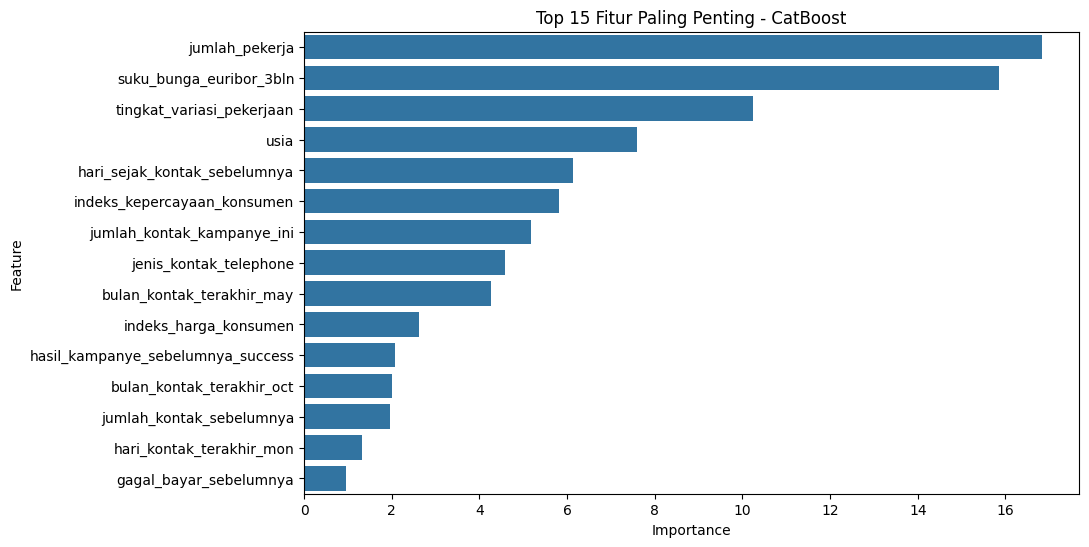

In [ ]:
feature_importance = best_catboost.get_feature_importance()
feature_names = X_train_encoded.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Fitur Paling Penting - CatBoost')
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('catboost', best_catboost),
    ('lightgbm', LGBMClassifier(random_state=42))
], voting='soft', weights=[0.7, 0.3])  # Beri bobot lebih ke CatBoost

ensemble.fit(X_train_encoded, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2614, number of negative: 20302
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 505
[LightGBM] [Info] Number of data points in the train set: 22916, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.114069 -> initscore=-2.049838
[LightGBM] [Info] Start training from score -2.049838


VotingClassifier(estimators=[('catboost',
                              <catboost.core.CatBoostClassifier object at 0x7d41273bbb10>),
                             ('lightgbm', LGBMClassifier(random_state=42))],
                 voting='soft', weights=[0.7, 0.3])